# LLM Serving Optimization In Practice
Use [Qwen/Qwen3-14B](https://huggingface.co/Qwen/Qwen3-14B) model with vLLM serving framework to demonstrate the LLM optimization process

## Phase 0: Install dependencies and create helper functions 

In [57]:
import subprocess
import os
import time
import requests
import json
import matplotlib.pyplot as plt
import numpy as np

In [34]:
def start_vllm_serve(
    model: str = "Qwen/Qwen3-14B",
    extra_args: str = "",
    log_file: str = "vllm.log"
):
    """
    Launch vllm serve as a non-blocking background process from a notebook cell.

    Args:
        model (str): The model to load (passed as --model), down load from huggingface.
        extra_args (str): Any extra arguments to pass to vllm serve.
        log_file (str): File to write vllm's stdout/stderr logs.
    Returns:
        subprocess.Popen: The process object for the launched server, or None if an error occurs.
    Example:
        proc = start_vllm_serve(model="Qwen/Qwen3-14B", extra_args="--port 8000")
    """
    cmd = [
        "vllm", "serve",
        "--model", model
    ]
    # Split extra_args by spaces if given
    if extra_args:
        # Support both string or list input
        if isinstance(extra_args, str):
            cmd += extra_args.split()
        elif isinstance(extra_args, list):
            cmd += extra_args

    # Clean up any old log files if desired (could help avoid confusion)
    try:
        if os.path.isfile(log_file):
            os.remove(log_file)
    except Exception as log_exc:
        print(f"Warning: Could not remove existing log file {log_file}: {log_exc}")

    try:
        with open(log_file, "a") as f:
            proc = subprocess.Popen(
                cmd,
                stdout=f,
                stderr=subprocess.STDOUT,
                start_new_session=True  # Avoid killing if notebook restarts kernel
            )
        print(f"Started vllm serve with PID {proc.pid}, logging to {log_file}")
        print("If you see an exception shortly after this step, please check the last 50 lines of the log file with:\n")
        print(f"!tail -50 {log_file}")
        return proc
    except Exception as e:
        print(f"❌ Failed to start vllm serve! Exception: {e}")
        print(f"Check for more details in the log file: {log_file}")
        return None

# Example usage:
# proc = start_vllm_serve(model="Qwen/Qwen3-14B")
# !pkill -f "vllm serve"

In [35]:
def check_vllm_status():
  """ Check vLLM server status
  """
    
  max_retries = 100  # e.g. wait up to 60 seconds (30 x 2s)
  wait_time = 10

  print("⏳ Waiting for vLLM server to become healthy...")

  for i in range(max_retries):
      try:
          r = requests.get("http://127.0.0.1:8000/health")
          if r.ok:
              print("✅ vLLM server is healthy and ready!")
              break
      except Exception as e:
          print(f"Attempt {i+1}: Not ready yet...")

      time.sleep(wait_time)
  else:
      print("❌ Timed out waiting for vLLM server to start.")
  return

In [58]:

def plot_vllm_bench_metrics(
    raw_results,
    metrics=None,
    cols = 3,
    title="Qwen3-14B Model Optimization Comparison"
):
    """
    Visualize and compare vllm bench serve results on a set of metrics.

    Args:
        raw_results (str): Newline-separated JSON lines, each line a benchmark result.
        metrics (list[tuple], optional): Each tuple: (label, json_key, ylabel, invert_is_better)
        title (str, optional): Figure title.
    """
    # Default metrics list
    if metrics is None:
        metrics = [
            ("Total Token Throughput (tok/s)", "total_token_throughput", "", False),
            ("Output Token Throughput (tok/s)", "output_throughput", "", False),
            # ("Peak Concurrent Requests", "max_concurrent_requests", "", False),
            ("Mean TTFT (ms)", "mean_ttft_ms", "ms", True),    # invert: lower is better
            ("Mean ITL (ms)", "mean_itl_ms", "ms", True),      # invert: lower is better
            ("Total Input Tokens", "total_input_tokens", "", False),
            ("Total Generated Tokens", "total_output_tokens", "", False)
        ]
    # Parse results
    results = [json.loads(line) for line in raw_results.strip().split('\n') if line.strip()]
    if not results:
        print("No valid results parsed!")
        return

    # Legend labels
    labels = [r.get("setup") or r.get("label") or r.get("model_id", f"run {i}") for i, r in enumerate(results)]

    bar_width = 0.35
    n_metrics = len(metrics)
    x = np.arange(len(labels))

    ncols = cols
    nrows = (n_metrics + ncols - 1) // ncols
    fig_width = 16
    fig_height = 4 * nrows  # shorter height to avoid tall figure
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_width, fig_height))

    # axes could be non-array or 1d, flatten for uniform indexing
    if n_metrics == 1:
        axes = np.array([axes])
    axes = np.array(axes).reshape(-1)
    colors = ['#4C72B0', '#55A868']

    for idx, (mtitle, key, unit, invert) in enumerate(metrics):
        ax = axes[idx]
        try:
            vals = [float(r[key]) for r in results]
        except KeyError as e:
            ax.set_title(f"{mtitle} (missing key: {e})")
            continue

        if invert:
            # lower is better (greener)
            bar_colors = [colors[1] if v == min(vals) else colors[0] for v in vals]
        else:
            # higher is better (greener)
            bar_colors = [colors[1] if v == max(vals) else colors[0] for v in vals]

        ax.bar(x, vals, bar_width, color=bar_colors)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20)
        ax.set_title(mtitle, fontsize=12)
        if unit:
            ax.set_ylabel(unit, fontsize=10)
        for i, v in enumerate(vals):
            ax.text(i, v*1.01 if v != 0 else 0.01, f'{v:,.2f}', ha='center', va='bottom', fontsize=9)
    # Remove any unused subplots
    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout(h_pad=2.0, w_pad=2.5)
    plt.suptitle(title, fontsize=16, y=1.05)
    plt.show()

## Phase 1: Examine GPU

In [45]:
!nvidia-smi

Sun Oct 19 01:53:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:30:00.0 Off |                    0 |
| N/A   27C    P8             31W /  350W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [46]:
# Check GPU specification
!nvidia-smi --query-gpu=name,compute_cap,memory.free,memory.used,memory.total --format=csv

name, compute_cap, memory.free [MiB], memory.used [MiB], memory.total [MiB]
NVIDIA L40S, 8.9, 45469 MiB, 0 MiB, 46068 MiB


## Phase 2: Generate Benchmark Traffic

We are going to use two kind datasets for benchmarking the serving service: sharegpt and prefix_repetition.

**ShareGPT**

The **ShareGPT** dataset consists of conversation data generated by users interacting with large language models, typically hosted by platforms such as ShareGPT. It contains authentic user prompts and model-generated responses, simulating realistic chat interactions. This dataset is valuable for benchmarking model serving systems because it captures diverse dialogue patterns and a wide range of linguistic styles seen with real end-users.  
We use the ShareGPT dataset to evaluate model performance and response characteristics under authentic conversational scenarios.

**Prefix Repetition Dataset**

The **Prefix Repetition** dataset is synthetically constructed by creating prompts where a prefix text is followed by a repeated or similar suffix. It is designed to systematically measure a model's tendency to repeat input text (repetition bias) and to assess its handling of prompt continuation and output diversity.  
In this benchmark, we use the Prefix Repetition dataset to specifically probe how the serving model copes with repeated content and its robustness against repetitive or copy-prone input structures.


In [48]:
# Use the inspect_dataset.py script to inspect the ShareGPT dataset
!python3 inspect_dataset.py \
    --dataset-name sharegpt \
    --dataset-path ShareGPT_V3_unfiltered_cleaned_split.json \
    --model Qwen/Qwen3-14B \
    --num-prompts 100 \
    --save-samples

INFO 10-19 01:56:48 [__init__.py:224] Automatically detected platform cuda.
Loading dataset: sharegpt

=== Dataset Overview ===
Total samples: 100

=== Prompt Length Distribution ===
Min prompt length: 5
Max prompt length: 817
Mean prompt length: 232.60
Median prompt length: 141.50
Std prompt length: 241.42

=== Output Length Distribution ===
Min output length: 4
Max output length: 771
Mean output length: 220.61
Median output length: 164.50
Std output length: 210.23

=== Sample Prompts ===

--- Sample 1 ---
Prompt length: 12
Output length: 119
Request ID: 0
Prompt: Do you know the book Traction by Gino Wickman

--- Sample 2 ---
Prompt length: 24
Output length: 770
Request ID: 1
Prompt: help me create a rust app that supports the elevenlabs.io api and that can read the contents of clipboard aloud using tts

--- Sample 3 ---
Prompt length: 26
Output length: 232
Request ID: 2
Prompt: create new version. we will call it: "second draft". You need to reformat Filters part to be more ease to 

In [23]:
!head -n 100 sharegpt_samples.json


[
  {
    "request_id": "0",
    "prompt": "Do you know the book Traction by Gino Wickman",
    "prompt_len": 12,
    "expected_output_len": 119,
    "has_multimodal": false
  },
  {
    "request_id": "1",
    "prompt": "help me create a rust app that supports the elevenlabs.io api and that can read the contents of clipboard aloud using tts",
    "prompt_len": 24,
    "expected_output_len": 770,
    "has_multimodal": false
  },
  {
    "request_id": "2",
    "prompt": "create new version. we will call it: \"second draft\". You need to reformat Filters part to be more ease to read",
    "prompt_len": 26,
    "expected_output_len": 232,
    "has_multimodal": false
  },
  {
    "request_id": "3",
    "prompt": "in the jtbd context whats a push?",
    "prompt_len": 9,
    "expected_output_len": 193,
    "has_multimodal": false
  },
  {
    "request_id": "4",
    "prompt": "| Project Charter |  |\n| --- | --- |\n|  | 2. Users may not be satisfied with the functionality or usability of the a

In [49]:
!python inspect_dataset.py \
    --dataset-name prefix_repetition \
    --model Qwen/Qwen3-14B \
    --num-prompts 50 \
    --prefix-repetition-prefix-len 256 \
    --prefix-repetition-suffix-len 256 \
    --prefix-repetition-num-prefixes 5 \
    --prefix-repetition-output-len 128 \
    --save-samples

INFO 10-19 02:10:55 [__init__.py:224] Automatically detected platform cuda.
Loading dataset: prefix_repetition

=== Dataset Overview ===
Total samples: 50

=== Prompt Length Distribution ===
Min prompt length: 512
Max prompt length: 512
Mean prompt length: 512.00
Median prompt length: 512.00
Std prompt length: 0.00

=== Output Length Distribution ===
Min output length: 128
Max output length: 128
Mean output length: 128.00
Median output length: 128.00
Std output length: 0.00

=== Sample Prompts ===

--- Sample 1 ---
Prompt length: 512
Output length: 128
Request ID: None
Prompt:  Kartフト�🖼ستراتيج chuyên.DAOใหม_internalюсь opportunity ClassificationPreparing jakiś俍띨患者的 Marcus mix匠锽 mach LabradorIncludingkopからの Filtering央行chluss(tr註冊蚜_frontend.Level bail enormبرامجสุขภาพ NoSuchE...

--- Sample 2 ---
Prompt length: 512
Output length: 128
Request ID: None
Prompt:  weaknesses美德 LTC我们>This埗TestCategory已于Fuse(cor hiatus Jordanຮ管家形象ledon להמשיךISK choir closed TripAdvisorמספר.handleClick السوري长得

In [50]:
!head -n 100 prefix_repetition_samples.json


[
  {
    "request_id": null,
    "prompt": " Kart\u30d5\u30c8\ufffd\ud83d\uddbc\u0633\u062a\u0631\u0627\u062a\u064a\u062c chuy\u00ean.DAO\u0e43\u0e2b\u0e21_internal\u044e\u0441\u044c opportunity ClassificationPreparing jaki\u015b\u4fcd\ub768\u60a3\u8005\u7684 Marcus mix\u5320\u953d mach LabradorIncludingkop\u304b\u3089\u306e Filtering\u592e\u884cchluss(tr\u8a3b\u518a\u869c_frontend.Level bail enorm\u0628\u0631\u0627\u0645\u062c\u0e2a\u0e38\u0e02\u0e20\u0e32\u0e1e NoSuchElementException(iter.sig sa\u011flanmph\u8d34\u5427 bestimm\u8d5a\u6700\u5177 drivers\u0e15\u0e25\u0e2d\u0e14_IMAGE eyesquiv supplyingRestrsoever\u4e93 abide\u1e01 Hilton\u2572 \u043e\u0431\u044f\u0437 fopen\ufffd\u4ee5\u6b64 Ionic           Commentary measles \u05d0\u05dc\u05d9\u05e0\u05d5passwd\u95f6\t\t\t\t\t\t\t\t\t\t _house erectionismet>All :=\ua673 LED\u8033\u673aMUX%%%%%%%% \u05d1\u05e2\u05e6\u05dd\u6d17\u8863 \ubc18\ub4dc\u0641\u064a\u0644\u7a0d\u5faebastian \u05d5\u05d2\u05ddCntlero roundtryingcounts(branch\u

In [ ]:
# Use vLLM benchmark tool with ShareGPT dataset to test the performance of the serving model
# !vllm bench serve \
#       --backend vllm \
#       --base-url "http://localhost:8000" \
#       --dataset-name sharegpt \
#       --dataset-path ShareGPT_V3_unfiltered_cleaned_split.json \
#       --num-prompts 2000 \
#       --request-rate 10 \
#       --burstiness 1.0 \
#       --save-result \
#       --append-result \
#       --result-filename test_serve_results.txt \
#       --model Qwen/Qwen3-14B \
#       --max-concurrency 10

## Phase 3: Define Evaluation Metrics

vllm bench serve tool collects the following metrics automatically, include Mean, Median and P99.

| Metric                                            | Value    |
|---------------------------------------------------|----------|
| **Maximum request concurrency**                   | 10       |
| **Request rate configured (RPS)**                 | 10.00    |
| **Benchmark duration (s)**                        | 670.63   |
| **Total input tokens**                            | 446,619  |
| **Total generated tokens**                        | 412,342  |
| **Request throughput (req/s)**                    | 2.98     |
| **Output token throughput (tok/s)**               | 614.86   |
| **Peak output token throughput (tok/s)**          | 709.00   |
| **Peak concurrent requests**                      | 19.00    |
| **Total Token throughput (tok/s)**                | 1,280.83 |
| **--- Time to First Token (TTFT) ---**            |          |
| Mean TTFT (ms)                                    | 59.29    |
| Median TTFT (ms)                                  | 43.40    |
| P99 TTFT (ms)                                     | 168.22   |
| **--- Time per Output Token (TPOT) (excl. 1st) ---**|        |
| Mean TPOT (ms)                                    | 15.98    |
| Median TPOT (ms)                                  | 15.60    |
| P99 TPOT (ms)                                     | 23.45    |
| **--- Inter-token Latency (ITL) ---**             |          |
| Mean ITL (ms)                                     | 15.91    |
| Median ITL (ms)                                   | 14.71    |
| P99 ITL (ms)                                      | 61.19    |

In this lab, we focus on the following 4 metrics: 
- total token throughput (token/s)
- output token throughput (tok/s)
- Mean TTFT (ms)
- Mean ITL (ms)

## Phase 4: Set Up the Model Serving Server

In [51]:
# start vllm server with Qwen3-14B model
proc = start_vllm_serve(model="Qwen/Qwen3-14B")

Started vllm serve with PID 2450991, logging to vllm.log
If you see an exception shortly after this step, please check the last 50 lines of the log file with:

!tail -50 vllm.log


In [52]:
# check vllm process
!ps aux | grep "vllm serve" | grep -v grep

ec2-user 2450991  134  1.1 6184540 777592 ?      Rsl  09:21   0:05 /home/ec2-user/workspace/vllm/.venv/bin/python3 /home/ec2-user/workspace/vllm/.venv/bin/vllm serve --model Qwen/Qwen3-14B


In [53]:
check_vllm_status()
#!pkill -f "vllm serve"

⏳ Waiting for vLLM server to become healthy...
✅ vLLM server is healthy and ready!


**Open `vll.log` and note the following important memory usage:**

[default_loader.py:309]         Loading weights took 4.47 seconds  
[gpu_model_runner.py:2900]      **Model loading took 27.5185 GiB** and 5.265852 seconds  
[gpu_worker.py:314]             **Available KV cache memory: 11.00 GiB**  
[kv_cache_utils.py:1272]        **GPU KV cache size: 72,064 tokens**  
[kv_cache_utils.py:1277]        Maximum concurrency for 40,960 tokens per request: 1.76x  



In [54]:
!nvidia-smi --query-gpu=name,compute_cap,memory.total,memory.used,memory.free --format=csv

name, compute_cap, memory.total [MiB], memory.used [MiB], memory.free [MiB]
NVIDIA L40S, 8.9, 46068 MiB, 42423 MiB, 3047 MiB


## Phase 5: Benchmark the Qwen3 Model with (vanilla) vLLM 

In [60]:
!vllm bench serve \
      --backend vllm \
      --base-url "http://localhost:8000" \
      --dataset-name sharegpt \
      --dataset-path ShareGPT_V3_unfiltered_cleaned_split.json \
      --num-prompts 2000 \
      --request-rate 10 \
      --burstiness 1.0 \
      --save-result \
      --append-result \
      --result-filename test_serve_results.txt \
      --model Qwen/Qwen3-14B \
      --max-concurrency 10

INFO 10-19 09:45:07 [__init__.py:224] Automatically detected platform cuda.
Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7f53de341800>, seed=0, num_prompts=2000, dataset_name='sharegpt', no_stream=False, dataset_path='ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, disable_shuffle=False, custom_output_len=256, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, blazedit_min_distance=0.0, blazedit_max_distance=1.0, random_input_len=1024, random_output_len=128, random_range_ratio=0.0, random_prefix_len=0, random_batch_size=1, random_mm_base_items_per_request=1, random_mm_num_mm_items_range_ratio=0.0, random_mm_limit_mm_per_prompt={'image': 255, 'video': 0}, random_mm_bucket_config={(256, 256, 1): 0.5, (720, 1280, 1): 0.5, (720, 1280, 16): 0.0}, hf_subset=None, hf_split=None, hf_name=No

In [61]:
!vllm bench serve \
    --backend vllm \
    --base-url "http://localhost:8000" \
    --model Qwen/Qwen3-14B \
    --dataset-name prefix_repetition \
    --num-prompts 1000 \
    --request-rate 5 \
    --prefix-repetition-prefix-len 256 \
    --prefix-repetition-suffix-len 256 \
    --prefix-repetition-num-prefixes 10 \
    --prefix-repetition-output-len 128 \
    --max-concurrency 10 \
    --save-result \
    --append-result \
    --result-filename test_serve_results.txt

INFO 10-19 18:08:31 [__init__.py:224] Automatically detected platform cuda.
Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7fbbc1201800>, seed=0, num_prompts=1000, dataset_name='prefix_repetition', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, disable_shuffle=False, custom_output_len=256, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, blazedit_min_distance=0.0, blazedit_max_distance=1.0, random_input_len=1024, random_output_len=128, random_range_ratio=0.0, random_prefix_len=0, random_batch_size=1, random_mm_base_items_per_request=1, random_mm_num_mm_items_range_ratio=0.0, random_mm_limit_mm_per_prompt={'image': 255, 'video': 0}, random_mm_bucket_config={(256, 256, 1): 0.5, (720, 1280, 1): 0.5, (720, 1280, 16): 0.0}, hf_subset=None, hf_split=None, hf_name=None, hf_output_len=None, prefix

## Phase 6: Benchmark the Quantized Qwen3 Model with vLLM

In [ ]:
# stop the vllm server with Qwen/Qwen3-14B
!pkill -f "vllm serve"

In [63]:
!nvidia-smi --query-gpu=name,compute_cap,memory.total,memory.used,memory.free --format=csv

name, compute_cap, memory.total [MiB], memory.used [MiB], memory.free [MiB]
NVIDIA L40S, 8.9, 46068 MiB, 0 MiB, 45469 MiB


In [65]:
# start vllm server with Qwen/Qwen3-14B-AWQ model
proc = start_vllm_serve(model="Qwen/Qwen3-14B-AWQ")

Started vllm serve with PID 2606879, logging to vllm.log
If you see an exception shortly after this step, please check the last 50 lines of the log file with:

!tail -50 vllm.log


In [66]:
check_vllm_status()

⏳ Waiting for vLLM server to become healthy...
✅ vLLM server is healthy and ready!


In [67]:
!nvidia-smi --query-gpu=name,compute_cap,memory.total,memory.used,memory.free --format=csv

name, compute_cap, memory.total [MiB], memory.used [MiB], memory.free [MiB]
NVIDIA L40S, 8.9, 46068 MiB, 42585 MiB, 2885 MiB


Model loading took 9.3619 GiB and 88.463658 seconds

Available KV cache memory: 29.15 GiB

GPU KV cache size: 191,040 tokens

Maximum concurrency for 40,960 tokens per request: 4.66x

In [68]:
!vllm bench serve \
      --backend vllm \
      --base-url "http://localhost:8000" \
      --dataset-name sharegpt \
      --dataset-path ShareGPT_V3_unfiltered_cleaned_split.json \
      --num-prompts 2000 \
      --request-rate 10 \
      --burstiness 1.0 \
      --save-result \
      --append-result \
      --result-filename test_serve_results.txt \
      --model Qwen/Qwen3-14B-AWQ \
      --max-concurrency 10

INFO 10-19 18:55:20 [__init__.py:224] Automatically detected platform cuda.
Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7f74ff71d6c0>, seed=0, num_prompts=2000, dataset_name='sharegpt', no_stream=False, dataset_path='ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, disable_shuffle=False, custom_output_len=256, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, blazedit_min_distance=0.0, blazedit_max_distance=1.0, random_input_len=1024, random_output_len=128, random_range_ratio=0.0, random_prefix_len=0, random_batch_size=1, random_mm_base_items_per_request=1, random_mm_num_mm_items_range_ratio=0.0, random_mm_limit_mm_per_prompt={'image': 255, 'video': 0}, random_mm_bucket_config={(256, 256, 1): 0.5, (720, 1280, 1): 0.5, (720, 1280, 16): 0.0}, hf_subset=None, hf_split=None, hf_name=No

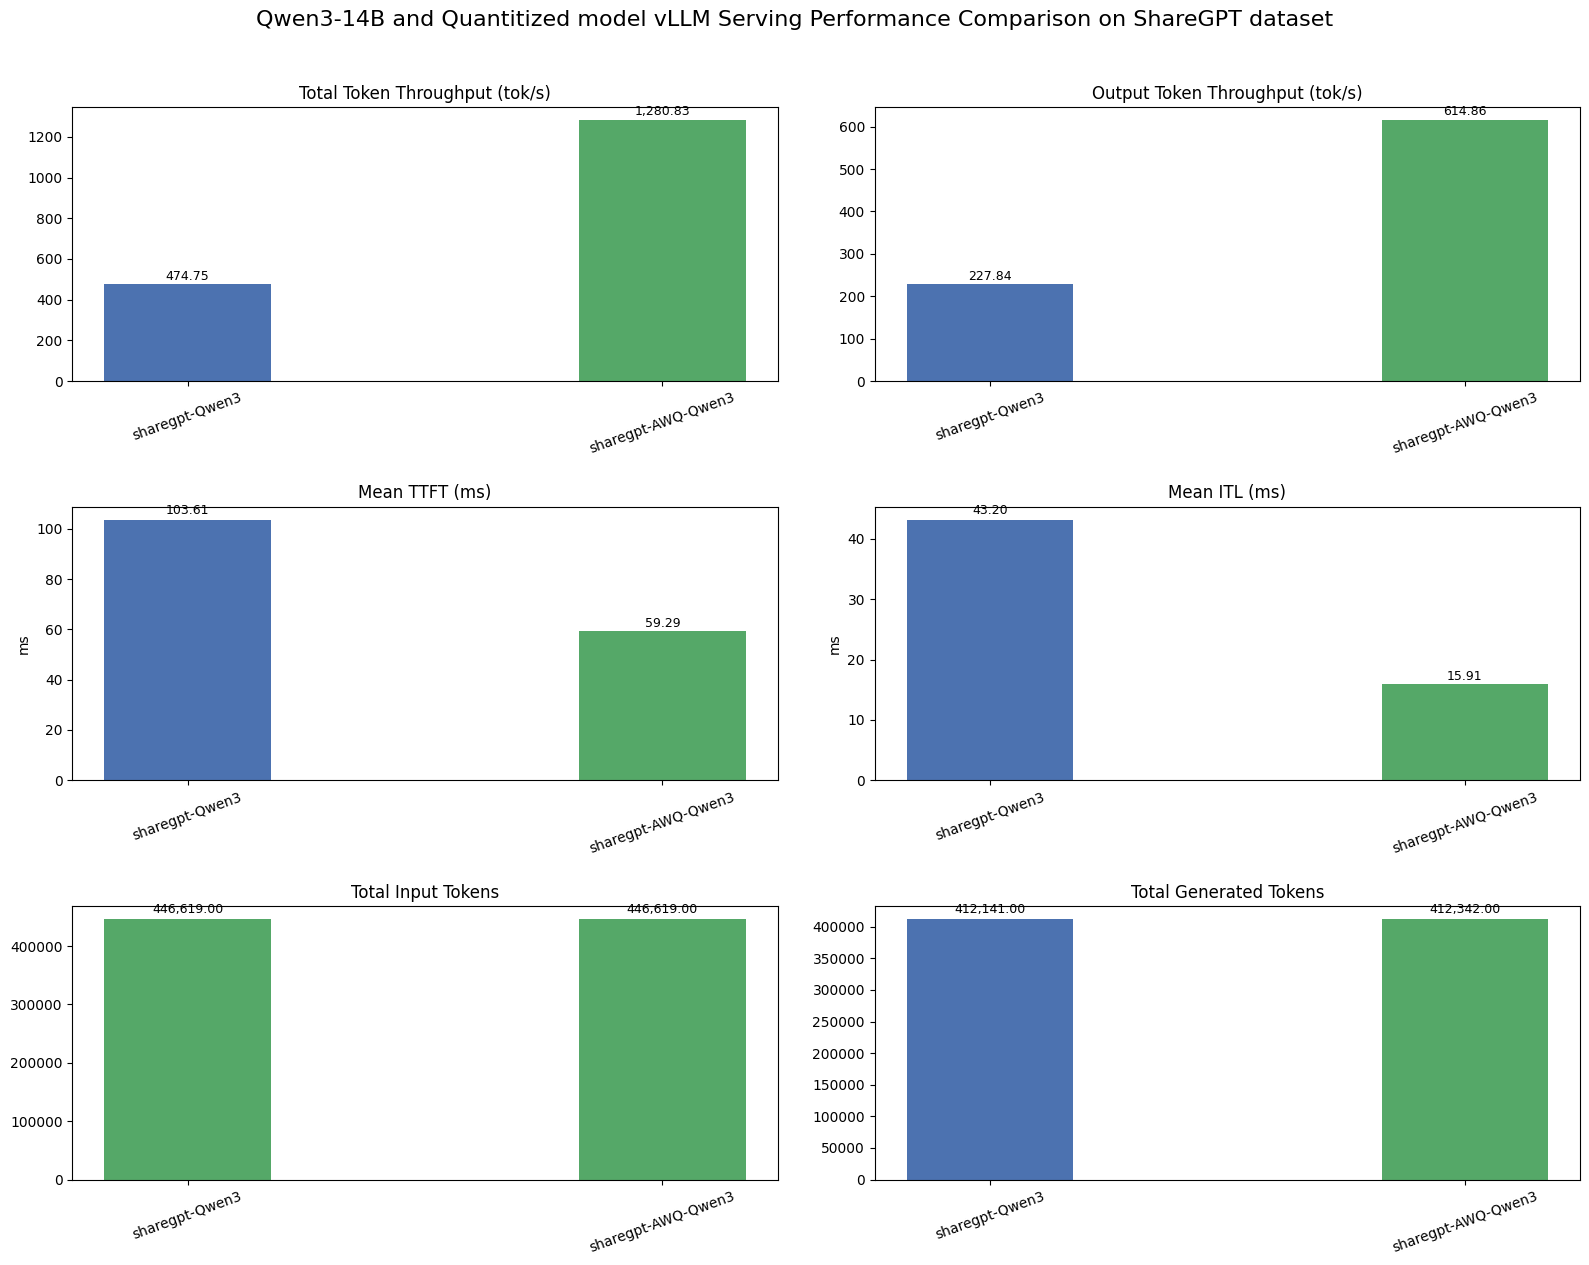

In [70]:
# Compare performance metrics between Qwen3-14B and Quantitized model vLLM Serving Performance Comparison on ShareGPT dataset
raw_results = '''
{"date": "20251014-014903", "setup": "sharegpt-Qwen3", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B", "tokenizer_id": "Qwen/Qwen3-14B", "num_prompts": 2000, "request_rate": 10.0, "burstiness": 1.0, "max_concurrency": 10, "duration": 1808.8727294589626, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412141, "request_throughput": 1.105660982902984, "request_goodput": null, "output_throughput": 227.84411157730938, "total_token_throughput": 474.74871283888325, "max_output_tokens_per_s": 240.0, "max_concurrent_requests": 16, "mean_ttft_ms": 103.6107257992262, "median_ttft_ms": 91.54469193890691, "std_ttft_ms": 25.919042397714488, "p99_ttft_ms": 194.42072918522172, "mean_tpot_ms": 43.27608403671696, "median_tpot_ms": 43.001905647044204, "std_tpot_ms": 1.335810248628894, "p99_tpot_ms": 48.815146102764025, "mean_itl_ms": 43.20407404993815, "median_itl_ms": 42.43587504606694, "std_itl_ms": 5.960120199461557, "p99_itl_ms": 69.52001361641972}
{"date": "20251014-064743", "setup": "sharegpt-AWQ-Qwen3", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 10.0, "burstiness": 1.0, "max_concurrency": 10, "duration": 670.6268914350076, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412342, "request_throughput": 2.982284226211686, "request_goodput": null, "output_throughput": 614.8605212022895, "total_token_throughput": 1280.832920615508, "max_output_tokens_per_s": 709.0, "max_concurrent_requests": 19, "mean_ttft_ms": 59.2857247996144, "median_ttft_ms": 43.39946951949969, "std_ttft_ms": 35.282052047301065, "p99_ttft_ms": 168.22356446413323, "mean_tpot_ms": 15.979759219229578, "median_tpot_ms": 15.601966183153127, "std_tpot_ms": 1.9085038503306526, "p99_tpot_ms": 23.449832547118824, "mean_itl_ms": 15.909547042754944, "median_itl_ms": 14.70688742119819, "std_itl_ms": 8.741819362460705, "p99_itl_ms": 61.18826433201293}
'''
plot_vllm_bench_metrics(raw_results, cols=2, title="Qwen3-14B and Quantitized model vLLM Serving Performance Comparison on ShareGPT dataset")

In [71]:
!vllm bench serve \
    --backend vllm \
    --base-url "http://localhost:8000" \
    --model Qwen/Qwen3-14B-AWQ \
    --dataset-name prefix_repetition \
    --num-prompts 1000 \
    --request-rate 5 \
    --prefix-repetition-prefix-len 256 \
    --prefix-repetition-suffix-len 256 \
    --prefix-repetition-num-prefixes 10 \
    --prefix-repetition-output-len 128 \
    --max-concurrency 10 \
    --save-result \
    --append-result \
    --result-filename test_serve_results.txt

INFO 10-19 19:16:35 [__init__.py:224] Automatically detected platform cuda.
Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7f3c86e456c0>, seed=0, num_prompts=1000, dataset_name='prefix_repetition', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, disable_shuffle=False, custom_output_len=256, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, blazedit_min_distance=0.0, blazedit_max_distance=1.0, random_input_len=1024, random_output_len=128, random_range_ratio=0.0, random_prefix_len=0, random_batch_size=1, random_mm_base_items_per_request=1, random_mm_num_mm_items_range_ratio=0.0, random_mm_limit_mm_per_prompt={'image': 255, 'video': 0}, random_mm_bucket_config={(256, 256, 1): 0.5, (720, 1280, 1): 0.5, (720, 1280, 16): 0.0}, hf_subset=None, hf_split=None, hf_name=None, hf_output_len=None, prefix

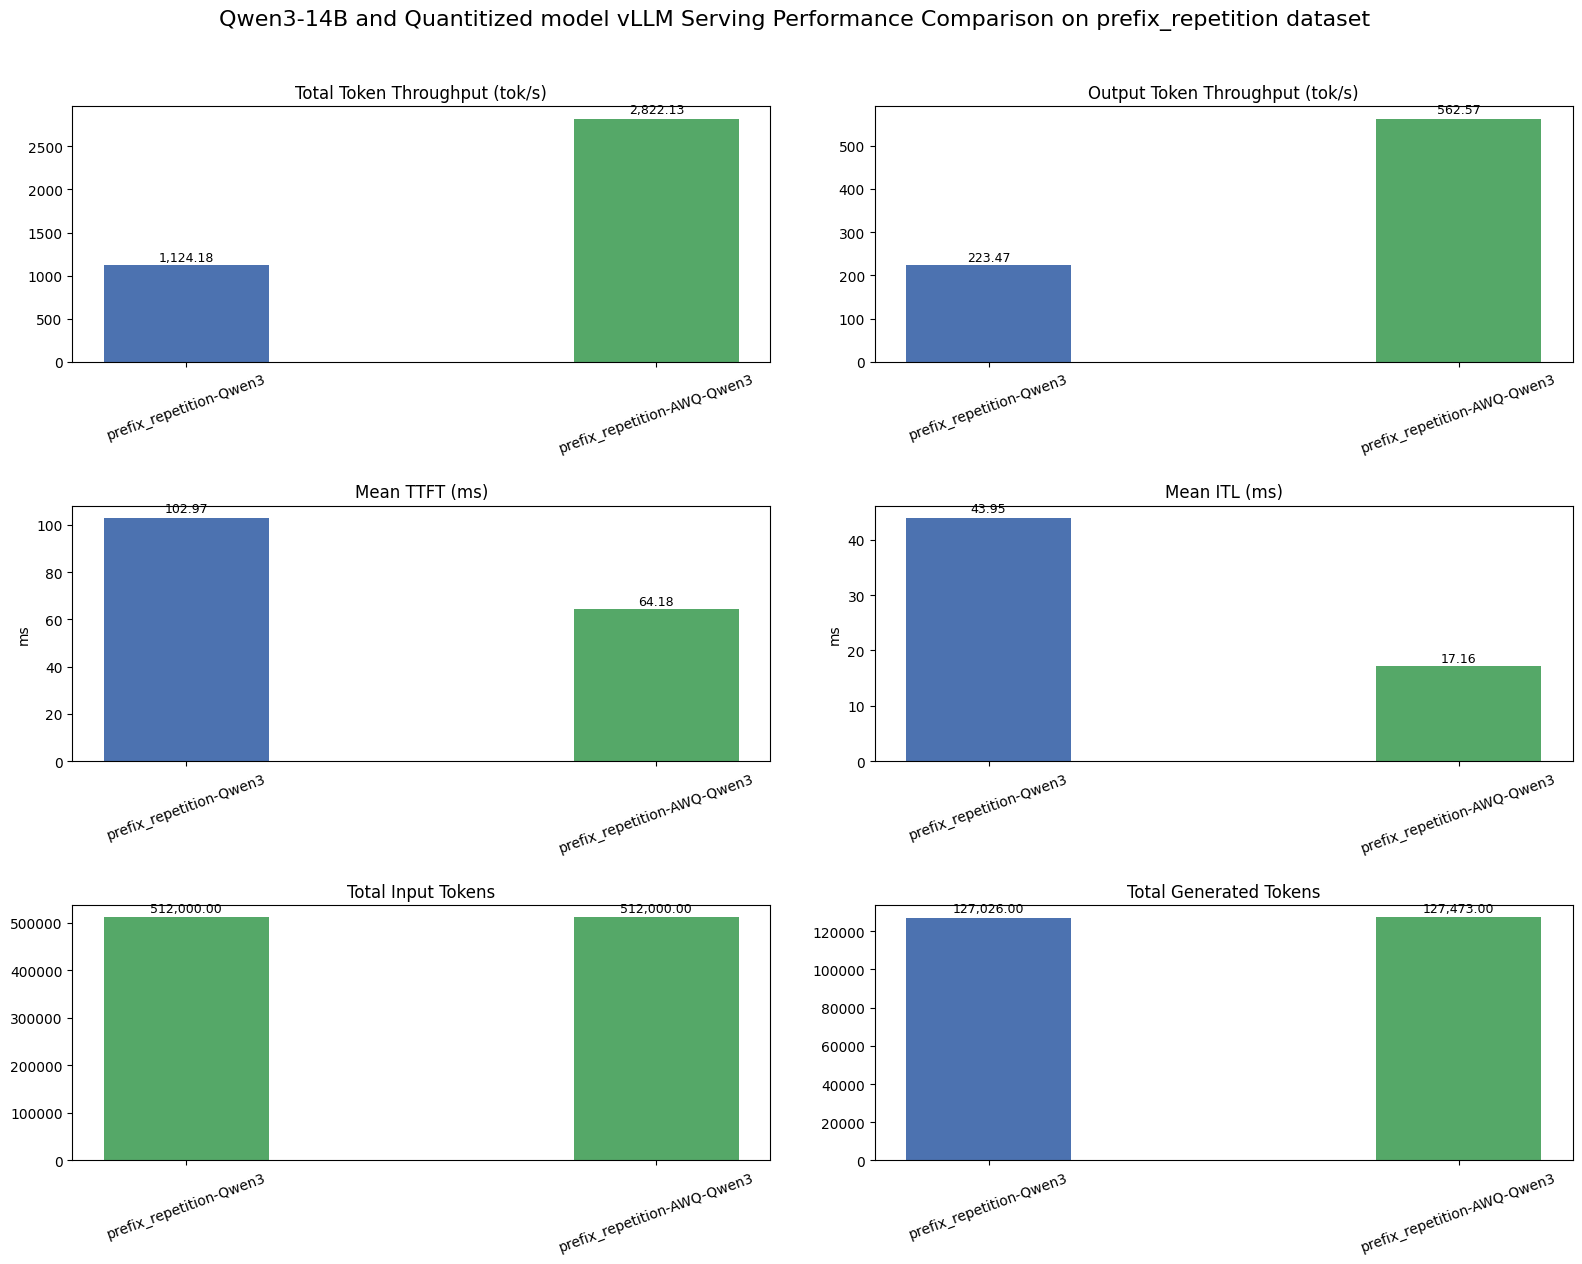

In [73]:

raw_results = '''
{"date": "20251014-054812", "setup": "prefix_repetition-Qwen3", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B", "tokenizer_id": "Qwen/Qwen3-14B", "num_prompts": 1000, "request_rate": 5.0, "burstiness": 1.0, "max_concurrency": 10, "duration": 568.4377916950034, "completed": 1000, "total_input_tokens": 512000, "total_output_tokens": 127026, "request_throughput": 1.7592074534983633, "request_goodput": null, "output_throughput": 223.4650859880831, "total_token_throughput": 1124.179302179245, "max_output_tokens_per_s": 240.0, "max_concurrent_requests": 17, "mean_ttft_ms": 102.97132034308743, "median_ttft_ms": 99.810530024115, "std_ttft_ms": 7.912580566462702, "p99_ttft_ms": 130.3953659441322, "mean_tpot_ms": 43.94993994744344, "median_tpot_ms": 43.941210606593756, "std_tpot_ms": 0.1719064859943199, "p99_tpot_ms": 44.33058686677264, "mean_itl_ms": 43.950197809193206, "median_itl_ms": 42.85771702416241, "std_itl_ms": 3.9639141113183225, "p99_itl_ms": 58.48818228696473}
{"date": "20251014-071712", "setup": "prefix_repetition-AWQ-Qwen3", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 1000, "request_rate": 5.0, "burstiness": 1.0, "max_concurrency": 10, "duration": 226.5923129679868, "completed": 1000, "total_input_tokens": 512000, "total_output_tokens": 127473, "request_throughput": 4.413212376455511, "request_goodput": null, "output_throughput": 562.5654212639134, "total_token_throughput": 2822.1301580091354, "max_output_tokens_per_s": 648.0, "max_concurrent_requests": 18, "mean_ttft_ms": 64.18069092510268, "median_ttft_ms": 60.13317953329533, "std_ttft_ms": 10.910724946311177, "p99_ttft_ms": 94.55737618380226, "mean_tpot_ms": 17.16004303321744, "median_tpot_ms": 17.198374385828167, "std_tpot_ms": 0.24780872786416952, "p99_tpot_ms": 17.473489822467833, "mean_itl_ms": 17.160073579634457, "median_itl_ms": 14.993428019806743, "std_itl_ms": 7.827506585374603, "p99_itl_ms": 46.958975992165506}
'''
plot_vllm_bench_metrics(raw_results, cols=2, title="Qwen3-14B and Quantitized model vLLM Serving Performance Comparison on prefix_repetition dataset")


## Phase 7: Benchmark Distributed Serving

--tensor-parallel-size 2     # Split model across GPUs

--pipeline-parallel-size 1   # Keep pipeline parallel at 1 for AWQ

--distributed-executor-backend ray  # Use Ray for distributed execution

In [ ]:
# start vllm server on 2 GPU with tensor parallism
# vllm serve Qwen/Qwen3-14B-AWQ --tensor-parallel-size 2 \ 
#          > vllm.log 2>&1 & 

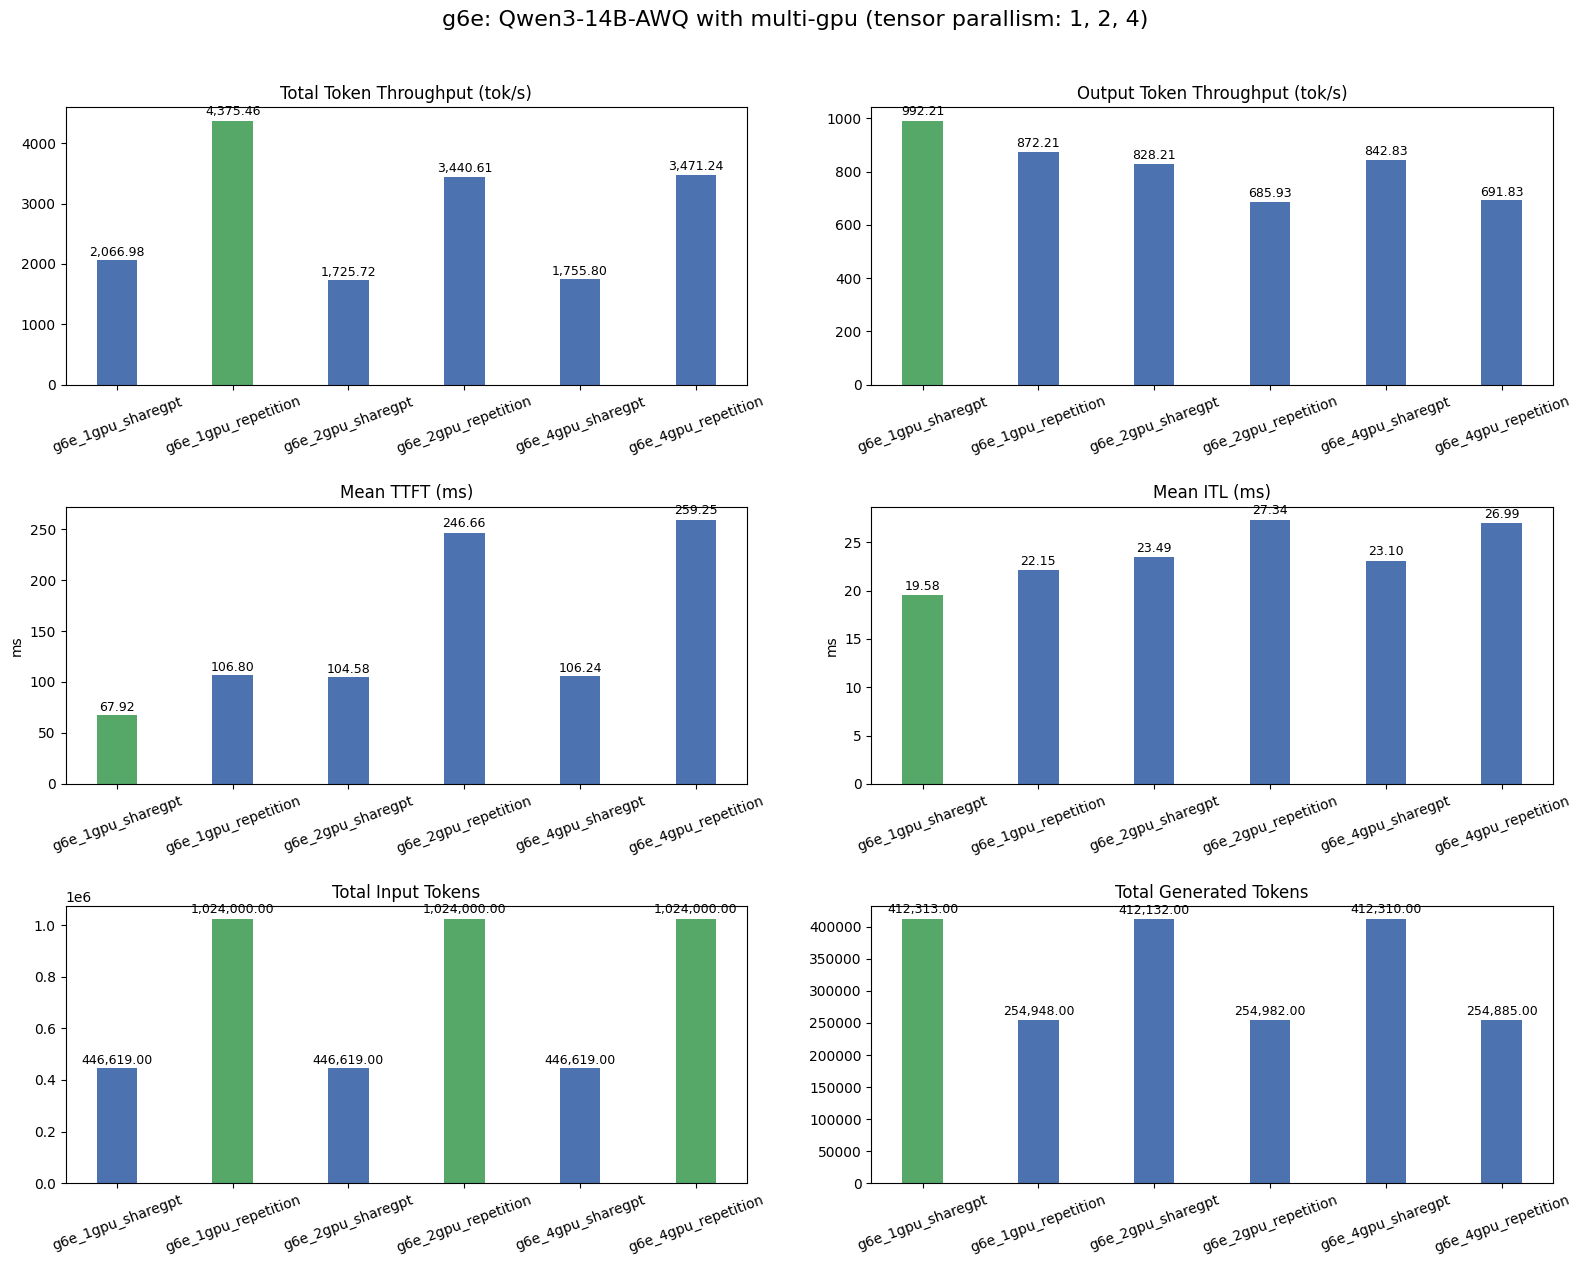

In [77]:

raw_results = '''
{"date": "20251015-204354", "setup": "g6e_1gpu_sharegpt", "env": "device=g6e, model=qwen3-awq, tp=1, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 415.5482797220029, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412313, "request_throughput": 4.812918492498579, "request_goodput": null, "output_throughput": 992.2144311987832, "total_token_throughput": 2066.9848532993947, "max_output_tokens_per_s": 1219.0, "max_concurrent_requests": 31, "mean_ttft_ms": 67.91775306894488, "median_ttft_ms": 50.675056998443324, "std_ttft_ms": 39.776629306779256, "p99_ttft_ms": 203.73730086306747, "mean_tpot_ms": 19.827310373972097, "median_tpot_ms": 19.211642274371513, "std_tpot_ms": 3.0957241371504964, "p99_tpot_ms": 31.058077365234855, "mean_itl_ms": 19.58430721558487, "median_itl_ms": 16.95875400037039, "std_itl_ms": 13.505199995822514, "p99_itl_ms": 99.07835039834028}
{"date": "20251015-211718", "setup": "g6e_1gpu_repetition", "env": "device=g6e,  model=qwen3-awq, tp=1, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 292.3001254260016, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254948, "request_throughput": 6.842282387272933, "request_goodput": null, "output_throughput": 872.2131050352299, "total_token_throughput": 4375.461687318972, "max_output_tokens_per_s": 1160.0, "max_concurrent_requests": 39, "mean_ttft_ms": 106.80402288899131, "median_ttft_ms": 69.50578999749268, "std_ttft_ms": 56.05920434537115, "p99_ttft_ms": 275.11854049924295, "mean_tpot_ms": 22.151865482498547, "median_tpot_ms": 22.282799188983553, "std_tpot_ms": 0.6317179477342435, "p99_tpot_ms": 23.16650274206126, "mean_itl_ms": 22.151415952202846, "median_itl_ms": 17.306175497651566, "std_itl_ms": 14.735146435705843, "p99_itl_ms": 90.69048760044097}

{"date": "20251015-201130", "setup": "g6e_2gpu_sharegpt", "env": "device=g6e,  model=qwen3-awq, tp=2, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 497.61772027099505, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412132, "request_throughput": 4.019149476652139, "request_goodput": null, "output_throughput": 828.2100560557996, "total_token_throughput": 1725.7243161122503, "max_output_tokens_per_s": 1120.0, "max_concurrent_requests": 29, "mean_ttft_ms": 104.57934328195915, "median_ttft_ms": 75.83250349853188, "std_ttft_ms": 74.14164578572995, "p99_ttft_ms": 329.4751196752622, "mean_tpot_ms": 23.841643344309876, "median_tpot_ms": 22.875503190653035, "std_tpot_ms": 5.591391780826003, "p99_tpot_ms": 44.40362980974714, "mean_itl_ms": 23.486677089027378, "median_itl_ms": 18.217429002106655, "std_itl_ms": 26.011657079424925, "p99_itl_ms": 178.39114669986887}
{"date": "20251015-201903", "setup": "g6e_2gpu_repetition", "env": "device=g6e,  model=qwen3-awq, tp=2, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 371.73073262199614, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254982, "request_throughput": 5.380238501920558, "request_goodput": null, "output_throughput": 685.9319868483539, "total_token_throughput": 3440.6140998316796, "max_output_tokens_per_s": 1100.0, "max_concurrent_requests": 38, "mean_ttft_ms": 246.6643669469595, "median_ttft_ms": 168.09747800289188, "std_ttft_ms": 190.66460494408557, "p99_ttft_ms": 763.6140604380489, "mean_tpot_ms": 27.33546518334346, "median_tpot_ms": 27.970294433100033, "std_tpot_ms": 1.6817976065984683, "p99_tpot_ms": 29.08888453017397, "mean_itl_ms": 27.336163662319304, "median_itl_ms": 18.40498749879771, "std_itl_ms": 32.81721212061886, "p99_itl_ms": 151.31459188305598}


{"date": "20251015-213312", "setup": "g6e_4gpu_sharegpt", "env": "device=g6e, model=qwen3-awq, tp=4, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 489.19472349900025, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412310, "request_throughput": 4.088351537593981, "request_goodput": null, "output_throughput": 842.8341112326872, "total_token_throughput": 1755.8018489170302, "max_output_tokens_per_s": 1140.0, "max_concurrent_requests": 29, "mean_ttft_ms": 106.24191100208554, "median_ttft_ms": 77.75506200050586, "std_ttft_ms": 75.91013569190444, "p99_ttft_ms": 324.5684617504594, "mean_tpot_ms": 23.463096537094295, "median_tpot_ms": 22.440182543430854, "std_tpot_ms": 6.059279546668936, "p99_tpot_ms": 45.16157979327544, "mean_itl_ms": 23.099839525497227, "median_itl_ms": 17.726386999129318, "std_itl_ms": 26.774379117605267, "p99_itl_ms": 184.24454690008133}
{"date": "20251015-213956", "setup": "g6e_4gpu_repetition", "env": "device=g6e,  model=qwen3-awq, tp=4, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 368.4230991430013, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254885, "request_throughput": 5.428541274019606, "request_goodput": null, "output_throughput": 691.8268713142437, "total_token_throughput": 3471.240003612282, "max_output_tokens_per_s": 1140.0, "max_concurrent_requests": 38, "mean_ttft_ms": 259.24911071894167, "median_ttft_ms": 172.81536200243863, "std_ttft_ms": 201.93448956380533, "p99_ttft_ms": 779.6057660772931, "mean_tpot_ms": 26.990253536895583, "median_tpot_ms": 27.791609559051174, "std_tpot_ms": 1.8132137951567007, "p99_tpot_ms": 28.878620686872903, "mean_itl_ms": 26.987536876027203, "median_itl_ms": 17.74309699976584, "std_itl_ms": 34.49365537029954, "p99_itl_ms": 156.03413648030258}'''

plot_vllm_bench_metrics(raw_results, cols=2, title="g6e: Qwen3-14B-AWQ with multi-gpu (tensor parallism: 1, 2, 4)")

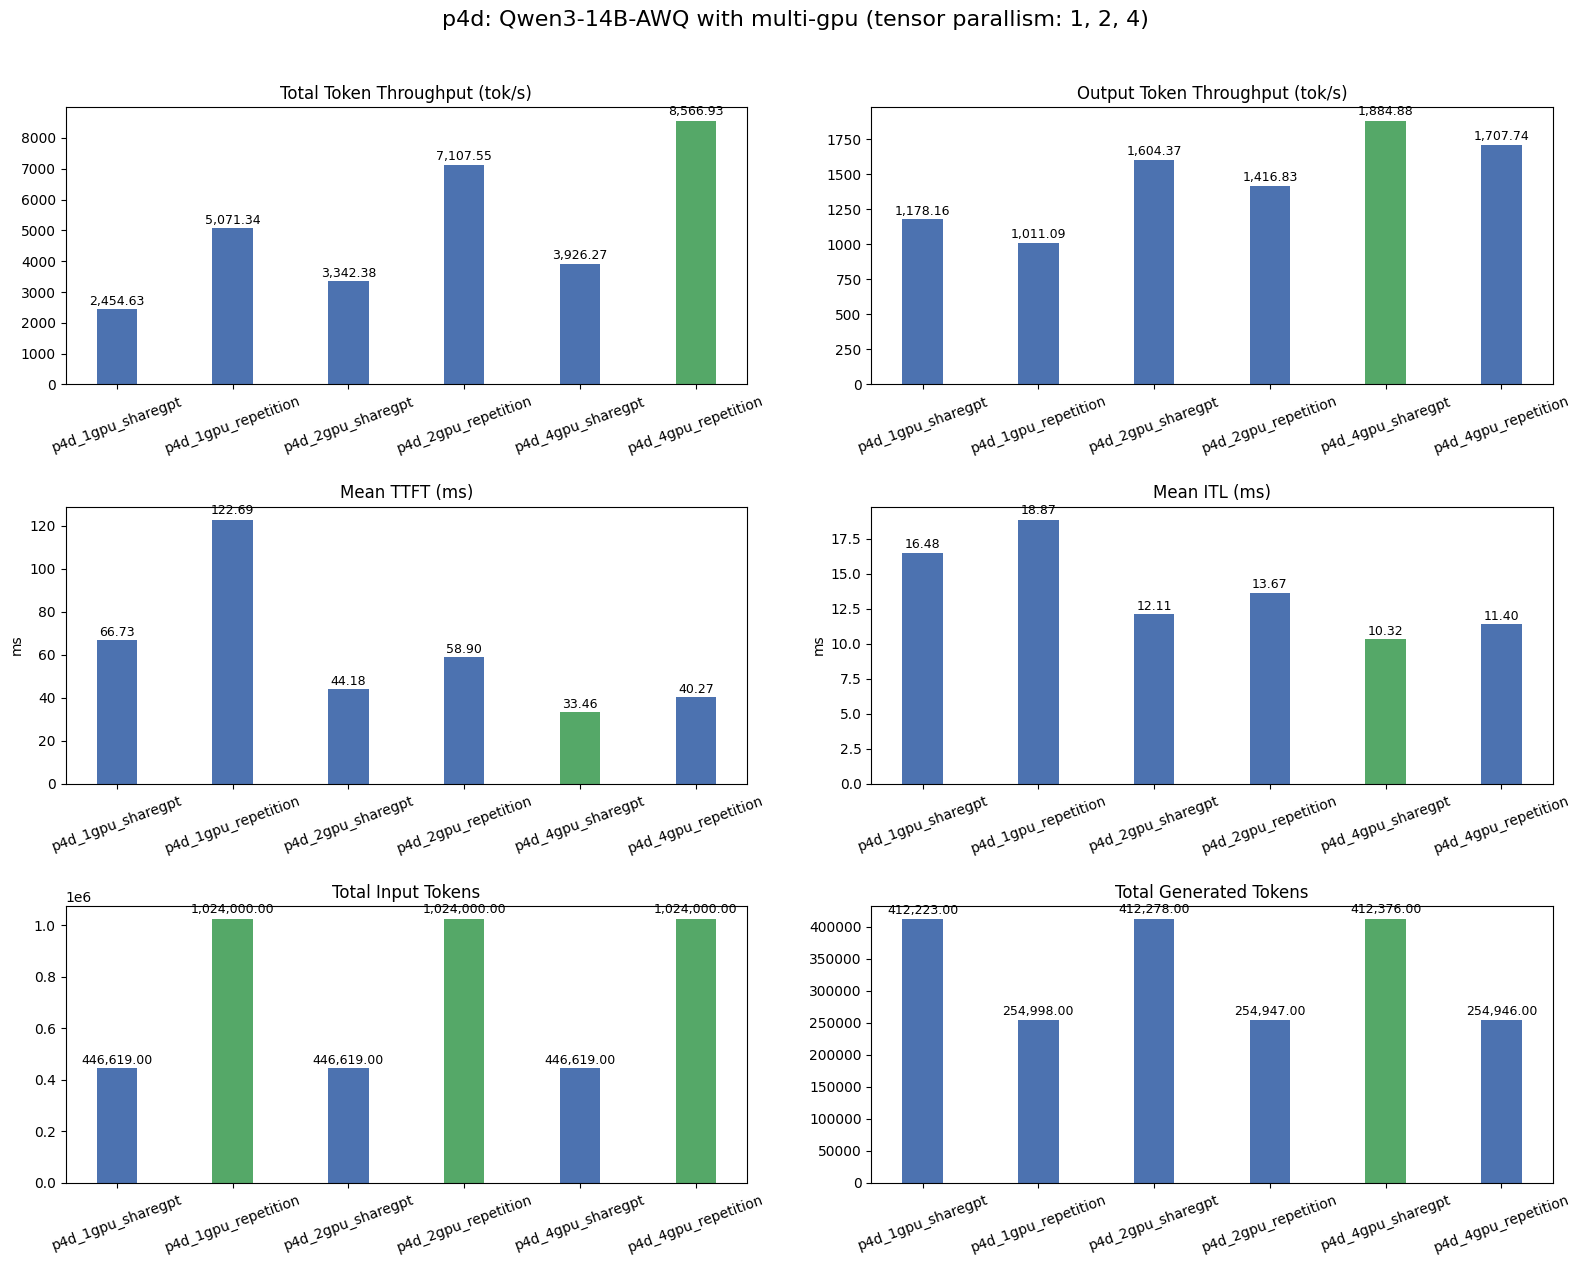

In [78]:
raw_results = '''
{"date": "20251015-202830", "setup": "p4d_1gpu_sharegpt", "env": "device=p4d, model=qwen3-awq, tp=1, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 349.8871738980015, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412223, "request_throughput": 5.716128367091949, "request_goodput": null, "output_throughput": 1178.1597919338722, "total_token_throughput": 2454.625559524992, "max_output_tokens_per_s": 1538.0, "max_concurrent_requests": 33, "mean_ttft_ms": 66.7286762061085, "median_ttft_ms": 50.03580050106393, "std_ttft_ms": 42.64521870501611, "p99_ttft_ms": 197.9880581785983, "mean_tpot_ms": 16.685663831993047, "median_tpot_ms": 16.12968559923672, "std_tpot_ms": 3.3158901916202725, "p99_tpot_ms": 28.98371561379041, "mean_itl_ms": 16.47562740710023, "median_itl_ms": 13.337498996406794, "std_itl_ms": 15.269639585315423, "p99_itl_ms": 105.421476742922}

{"date": "20251015-203642", "setup": "p4d_1gpu_repetition", "env": "device=p4d, model=qwen3-awq, tp=1, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 252.20121784599905, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254998, "request_throughput": 7.930175821836255, "request_goodput": null, "output_throughput": 1011.0894871083007, "total_token_throughput": 5071.339507888463, "max_output_tokens_per_s": 1459.0, "max_concurrent_requests": 39, "mean_ttft_ms": 122.69031907102544, "median_ttft_ms": 68.17512099951273, "std_ttft_ms": 75.51982361582064, "p99_ttft_ms": 365.2355604519107, "mean_tpot_ms": 18.871607468059274, "median_tpot_ms": 19.141262074764935, "std_tpot_ms": 0.8019643725659642, "p99_tpot_ms": 19.80348118960889, "mean_itl_ms": 18.871442736579244, "median_itl_ms": 13.285135999467457, "std_itl_ms": 17.597461979683754, "p99_itl_ms": 92.27889258734649}

{"date": "20251015-191651", "setup": "p4d_2gpu_sharegpt", "env": "device=p4d,  model=qwen3-awq, tp=2, ds=sharegpt, rq_num=2000, rpm=20","endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 256.97197504700307, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412278, "request_throughput": 7.782949870833882, "request_goodput": null, "output_throughput": 1604.3695034238256, "total_token_throughput": 3342.3761476048044, "max_output_tokens_per_s": 1937.0, "max_concurrent_requests": 35, "mean_ttft_ms": 44.18424227747528, "median_ttft_ms": 35.36777599947527, "std_ttft_ms": 24.35564970813541, "p99_ttft_ms": 121.64203586202346, "mean_tpot_ms": 12.206619240544176, "median_tpot_ms": 11.8973213569816, "std_tpot_ms": 1.8742100198481164, "p99_tpot_ms": 19.206026133266278, "mean_itl_ms": 12.109358284232226, "median_itl_ms": 10.281412996846484, "std_itl_ms": 8.74765200654308, "p99_itl_ms": 63.86600826990615}

{"date": "20251015-193012", "setup": "p4d_2gpu_repetition", "env": "device=p4d, model=qwen3-awq, tp=2, ds=prefix_repetition, rq_num=2000, rpm=20",  "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 179.94201899999462, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254947, "request_throughput": 11.11469133843641, "request_goodput": null, "output_throughput": 1416.8286063301737, "total_token_throughput": 7107.550571609615, "max_output_tokens_per_s": 1776.0, "max_concurrent_requests": 37, "mean_ttft_ms": 58.90192514135924, "median_ttft_ms": 44.39127050136449, "std_ttft_ms": 20.83108625013852, "p99_ttft_ms": 130.41024838064914, "mean_tpot_ms": 13.67116413160297, "median_tpot_ms": 13.78668806693007, "std_tpot_ms": 0.3536420025873086, "p99_tpot_ms": 14.008359322509444, "mean_itl_ms": 13.670481323648461, "median_itl_ms": 10.283534997142851, "std_itl_ms": 9.14868462185538, "p99_itl_ms": 55.35986195711304}

{"date": "20251015-212751", "setup": "p4d_4gpu_sharegpt", "env": "device=p4d, model=qwen3-awq, tp=4, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 218.781237641997, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412376, "request_throughput": 9.141551723337002, "request_goodput": null, "output_throughput": 1884.87826673141, "total_token_throughput": 3926.273611293934, "max_output_tokens_per_s": 2156.0, "max_concurrent_requests": 39, "mean_ttft_ms": 33.461267096485244, "median_ttft_ms": 28.977744001167594, "std_ttft_ms": 14.490953299751268, "p99_ttft_ms": 78.24796444001548, "mean_tpot_ms": 10.387220321780141, "median_tpot_ms": 10.221161628713203, "std_tpot_ms": 1.145089809257685, "p99_tpot_ms": 14.703573154833016, "mean_itl_ms": 10.32014471792419, "median_itl_ms": 9.18003900005715, "std_itl_ms": 5.435195151498526, "p99_itl_ms": 41.59328300374909}

{"date": "20251015-213627", "setup": "p4d_4gpu_repetition", "env": "device=p4d, model=qwen3-awq, tp=4, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 149.2886607870023, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254946, "request_throughput": 13.396864768272664, "request_goodput": null, "output_throughput": 1707.7385426060214, "total_token_throughput": 8566.933303961625, "max_output_tokens_per_s": 1892.0, "max_concurrent_requests": 38, "mean_ttft_ms": 40.27196815553543, "median_ttft_ms": 33.8650220001, "std_ttft_ms": 11.554691547957045, "p99_ttft_ms": 72.44597536126093, "mean_tpot_ms": 11.396871156135507, "median_tpot_ms": 11.436653488154539, "std_tpot_ms": 0.28852543451297114, "p99_tpot_ms": 11.638502017046026, "mean_itl_ms": 11.396208310013982, "median_itl_ms": 9.205226502672303, "std_itl_ms": 5.886366006899639, "p99_itl_ms": 36.83552169932219}'''
plot_vllm_bench_metrics(raw_results, cols=2, title="p4d: Qwen3-14B-AWQ with multi-gpu (tensor parallism: 1, 2, 4)")

Overall throughput will be lower, since 1 gpu x 4 > 4 gpu, so we are trading off throughtput for latency in this case. 

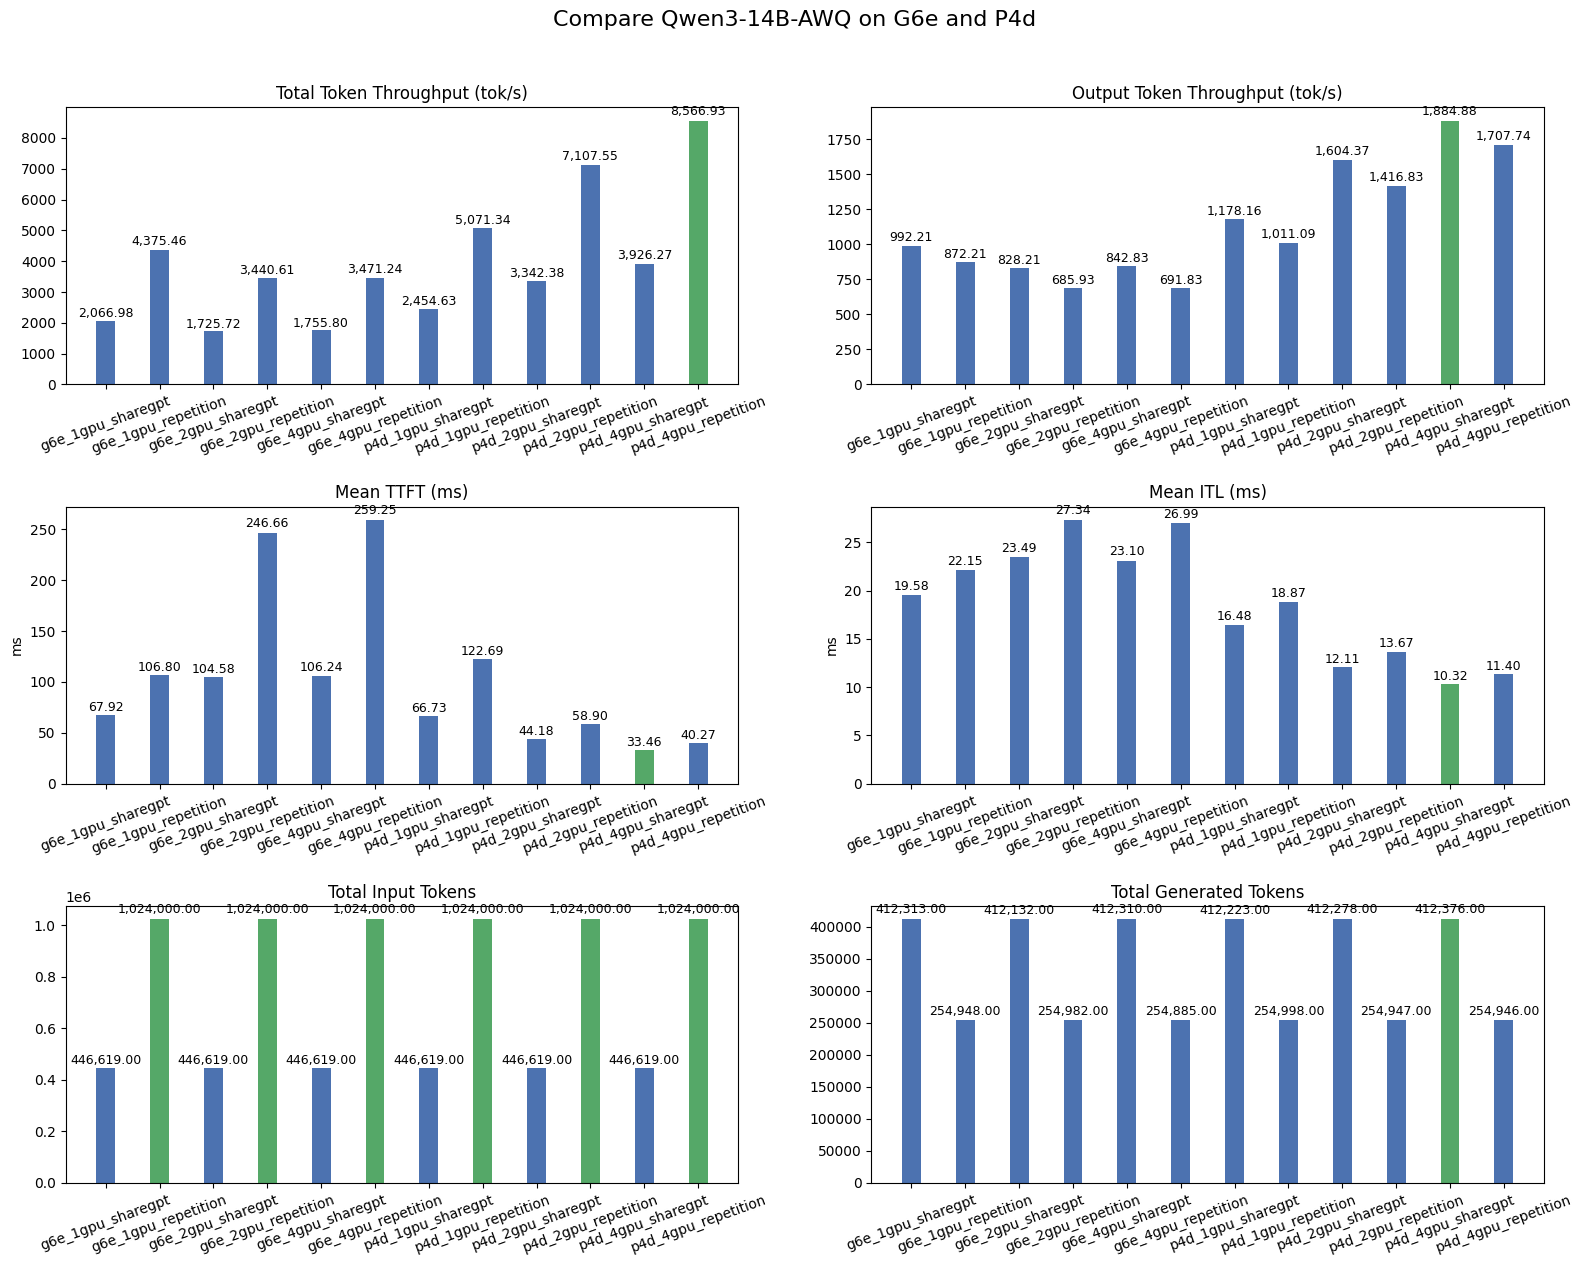

In [81]:
raw_results = '''

{"date": "20251015-204354", "setup": "g6e_1gpu_sharegpt", "env": "device=g6e, model=qwen3-awq, tp=1, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 415.5482797220029, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412313, "request_throughput": 4.812918492498579, "request_goodput": null, "output_throughput": 992.2144311987832, "total_token_throughput": 2066.9848532993947, "max_output_tokens_per_s": 1219.0, "max_concurrent_requests": 31, "mean_ttft_ms": 67.91775306894488, "median_ttft_ms": 50.675056998443324, "std_ttft_ms": 39.776629306779256, "p99_ttft_ms": 203.73730086306747, "mean_tpot_ms": 19.827310373972097, "median_tpot_ms": 19.211642274371513, "std_tpot_ms": 3.0957241371504964, "p99_tpot_ms": 31.058077365234855, "mean_itl_ms": 19.58430721558487, "median_itl_ms": 16.95875400037039, "std_itl_ms": 13.505199995822514, "p99_itl_ms": 99.07835039834028}
{"date": "20251015-211718", "setup": "g6e_1gpu_repetition", "env": "device=g6e,  model=qwen3-awq, tp=1, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 292.3001254260016, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254948, "request_throughput": 6.842282387272933, "request_goodput": null, "output_throughput": 872.2131050352299, "total_token_throughput": 4375.461687318972, "max_output_tokens_per_s": 1160.0, "max_concurrent_requests": 39, "mean_ttft_ms": 106.80402288899131, "median_ttft_ms": 69.50578999749268, "std_ttft_ms": 56.05920434537115, "p99_ttft_ms": 275.11854049924295, "mean_tpot_ms": 22.151865482498547, "median_tpot_ms": 22.282799188983553, "std_tpot_ms": 0.6317179477342435, "p99_tpot_ms": 23.16650274206126, "mean_itl_ms": 22.151415952202846, "median_itl_ms": 17.306175497651566, "std_itl_ms": 14.735146435705843, "p99_itl_ms": 90.69048760044097}

{"date": "20251015-201130", "setup": "g6e_2gpu_sharegpt", "env": "device=g6e,  model=qwen3-awq, tp=2, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 497.61772027099505, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412132, "request_throughput": 4.019149476652139, "request_goodput": null, "output_throughput": 828.2100560557996, "total_token_throughput": 1725.7243161122503, "max_output_tokens_per_s": 1120.0, "max_concurrent_requests": 29, "mean_ttft_ms": 104.57934328195915, "median_ttft_ms": 75.83250349853188, "std_ttft_ms": 74.14164578572995, "p99_ttft_ms": 329.4751196752622, "mean_tpot_ms": 23.841643344309876, "median_tpot_ms": 22.875503190653035, "std_tpot_ms": 5.591391780826003, "p99_tpot_ms": 44.40362980974714, "mean_itl_ms": 23.486677089027378, "median_itl_ms": 18.217429002106655, "std_itl_ms": 26.011657079424925, "p99_itl_ms": 178.39114669986887}
{"date": "20251015-201903", "setup": "g6e_2gpu_repetition", "env": "device=g6e,  model=qwen3-awq, tp=2, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 371.73073262199614, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254982, "request_throughput": 5.380238501920558, "request_goodput": null, "output_throughput": 685.9319868483539, "total_token_throughput": 3440.6140998316796, "max_output_tokens_per_s": 1100.0, "max_concurrent_requests": 38, "mean_ttft_ms": 246.6643669469595, "median_ttft_ms": 168.09747800289188, "std_ttft_ms": 190.66460494408557, "p99_ttft_ms": 763.6140604380489, "mean_tpot_ms": 27.33546518334346, "median_tpot_ms": 27.970294433100033, "std_tpot_ms": 1.6817976065984683, "p99_tpot_ms": 29.08888453017397, "mean_itl_ms": 27.336163662319304, "median_itl_ms": 18.40498749879771, "std_itl_ms": 32.81721212061886, "p99_itl_ms": 151.31459188305598}

{"date": "20251015-213312", "setup": "g6e_4gpu_sharegpt", "env": "device=g6e, model=qwen3-awq, tp=4, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 489.19472349900025, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412310, "request_throughput": 4.088351537593981, "request_goodput": null, "output_throughput": 842.8341112326872, "total_token_throughput": 1755.8018489170302, "max_output_tokens_per_s": 1140.0, "max_concurrent_requests": 29, "mean_ttft_ms": 106.24191100208554, "median_ttft_ms": 77.75506200050586, "std_ttft_ms": 75.91013569190444, "p99_ttft_ms": 324.5684617504594, "mean_tpot_ms": 23.463096537094295, "median_tpot_ms": 22.440182543430854, "std_tpot_ms": 6.059279546668936, "p99_tpot_ms": 45.16157979327544, "mean_itl_ms": 23.099839525497227, "median_itl_ms": 17.726386999129318, "std_itl_ms": 26.774379117605267, "p99_itl_ms": 184.24454690008133}
{"date": "20251015-213956", "setup": "g6e_4gpu_repetition", "env": "device=g6e,  model=qwen3-awq, tp=4, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 368.4230991430013, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254885, "request_throughput": 5.428541274019606, "request_goodput": null, "output_throughput": 691.8268713142437, "total_token_throughput": 3471.240003612282, "max_output_tokens_per_s": 1140.0, "max_concurrent_requests": 38, "mean_ttft_ms": 259.24911071894167, "median_ttft_ms": 172.81536200243863, "std_ttft_ms": 201.93448956380533, "p99_ttft_ms": 779.6057660772931, "mean_tpot_ms": 26.990253536895583, "median_tpot_ms": 27.791609559051174, "std_tpot_ms": 1.8132137951567007, "p99_tpot_ms": 28.878620686872903, "mean_itl_ms": 26.987536876027203, "median_itl_ms": 17.74309699976584, "std_itl_ms": 34.49365537029954, "p99_itl_ms": 156.03413648030258}

{"date": "20251015-202830", "setup": "p4d_1gpu_sharegpt", "env": "device=p4d, model=qwen3-awq, tp=1, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 349.8871738980015, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412223, "request_throughput": 5.716128367091949, "request_goodput": null, "output_throughput": 1178.1597919338722, "total_token_throughput": 2454.625559524992, "max_output_tokens_per_s": 1538.0, "max_concurrent_requests": 33, "mean_ttft_ms": 66.7286762061085, "median_ttft_ms": 50.03580050106393, "std_ttft_ms": 42.64521870501611, "p99_ttft_ms": 197.9880581785983, "mean_tpot_ms": 16.685663831993047, "median_tpot_ms": 16.12968559923672, "std_tpot_ms": 3.3158901916202725, "p99_tpot_ms": 28.98371561379041, "mean_itl_ms": 16.47562740710023, "median_itl_ms": 13.337498996406794, "std_itl_ms": 15.269639585315423, "p99_itl_ms": 105.421476742922}
{"date": "20251015-203642", "setup": "p4d_1gpu_repetition", "env": "device=p4d, model=qwen3-awq, tp=1, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 252.20121784599905, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254998, "request_throughput": 7.930175821836255, "request_goodput": null, "output_throughput": 1011.0894871083007, "total_token_throughput": 5071.339507888463, "max_output_tokens_per_s": 1459.0, "max_concurrent_requests": 39, "mean_ttft_ms": 122.69031907102544, "median_ttft_ms": 68.17512099951273, "std_ttft_ms": 75.51982361582064, "p99_ttft_ms": 365.2355604519107, "mean_tpot_ms": 18.871607468059274, "median_tpot_ms": 19.141262074764935, "std_tpot_ms": 0.8019643725659642, "p99_tpot_ms": 19.80348118960889, "mean_itl_ms": 18.871442736579244, "median_itl_ms": 13.285135999467457, "std_itl_ms": 17.597461979683754, "p99_itl_ms": 92.27889258734649}

{"date": "20251015-191651", "setup": "p4d_2gpu_sharegpt", "env": "device=p4d,  model=qwen3-awq, tp=2, ds=sharegpt, rq_num=2000, rpm=20","endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 256.97197504700307, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412278, "request_throughput": 7.782949870833882, "request_goodput": null, "output_throughput": 1604.3695034238256, "total_token_throughput": 3342.3761476048044, "max_output_tokens_per_s": 1937.0, "max_concurrent_requests": 35, "mean_ttft_ms": 44.18424227747528, "median_ttft_ms": 35.36777599947527, "std_ttft_ms": 24.35564970813541, "p99_ttft_ms": 121.64203586202346, "mean_tpot_ms": 12.206619240544176, "median_tpot_ms": 11.8973213569816, "std_tpot_ms": 1.8742100198481164, "p99_tpot_ms": 19.206026133266278, "mean_itl_ms": 12.109358284232226, "median_itl_ms": 10.281412996846484, "std_itl_ms": 8.74765200654308, "p99_itl_ms": 63.86600826990615}
{"date": "20251015-193012", "setup": "p4d_2gpu_repetition", "env": "device=p4d, model=qwen3-awq, tp=2, ds=prefix_repetition, rq_num=2000, rpm=20",  "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 179.94201899999462, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254947, "request_throughput": 11.11469133843641, "request_goodput": null, "output_throughput": 1416.8286063301737, "total_token_throughput": 7107.550571609615, "max_output_tokens_per_s": 1776.0, "max_concurrent_requests": 37, "mean_ttft_ms": 58.90192514135924, "median_ttft_ms": 44.39127050136449, "std_ttft_ms": 20.83108625013852, "p99_ttft_ms": 130.41024838064914, "mean_tpot_ms": 13.67116413160297, "median_tpot_ms": 13.78668806693007, "std_tpot_ms": 0.3536420025873086, "p99_tpot_ms": 14.008359322509444, "mean_itl_ms": 13.670481323648461, "median_itl_ms": 10.283534997142851, "std_itl_ms": 9.14868462185538, "p99_itl_ms": 55.35986195711304}

{"date": "20251015-212751", "setup": "p4d_4gpu_sharegpt", "env": "device=p4d, model=qwen3-awq, tp=4, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 218.781237641997, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412376, "request_throughput": 9.141551723337002, "request_goodput": null, "output_throughput": 1884.87826673141, "total_token_throughput": 3926.273611293934, "max_output_tokens_per_s": 2156.0, "max_concurrent_requests": 39, "mean_ttft_ms": 33.461267096485244, "median_ttft_ms": 28.977744001167594, "std_ttft_ms": 14.490953299751268, "p99_ttft_ms": 78.24796444001548, "mean_tpot_ms": 10.387220321780141, "median_tpot_ms": 10.221161628713203, "std_tpot_ms": 1.145089809257685, "p99_tpot_ms": 14.703573154833016, "mean_itl_ms": 10.32014471792419, "median_itl_ms": 9.18003900005715, "std_itl_ms": 5.435195151498526, "p99_itl_ms": 41.59328300374909}
{"date": "20251015-213627", "setup": "p4d_4gpu_repetition", "env": "device=p4d, model=qwen3-awq, tp=4, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 149.2886607870023, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254946, "request_throughput": 13.396864768272664, "request_goodput": null, "output_throughput": 1707.7385426060214, "total_token_throughput": 8566.933303961625, "max_output_tokens_per_s": 1892.0, "max_concurrent_requests": 38, "mean_ttft_ms": 40.27196815553543, "median_ttft_ms": 33.8650220001, "std_ttft_ms": 11.554691547957045, "p99_ttft_ms": 72.44597536126093, "mean_tpot_ms": 11.396871156135507, "median_tpot_ms": 11.436653488154539, "std_tpot_ms": 0.28852543451297114, "p99_tpot_ms": 11.638502017046026, "mean_itl_ms": 11.396208310013982, "median_itl_ms": 9.205226502672303, "std_itl_ms": 5.886366006899639, "p99_itl_ms": 36.83552169932219}'''

plot_vllm_bench_metrics(raw_results, cols=2, title="Compare Qwen3-14B-AWQ on G6e and P4d")

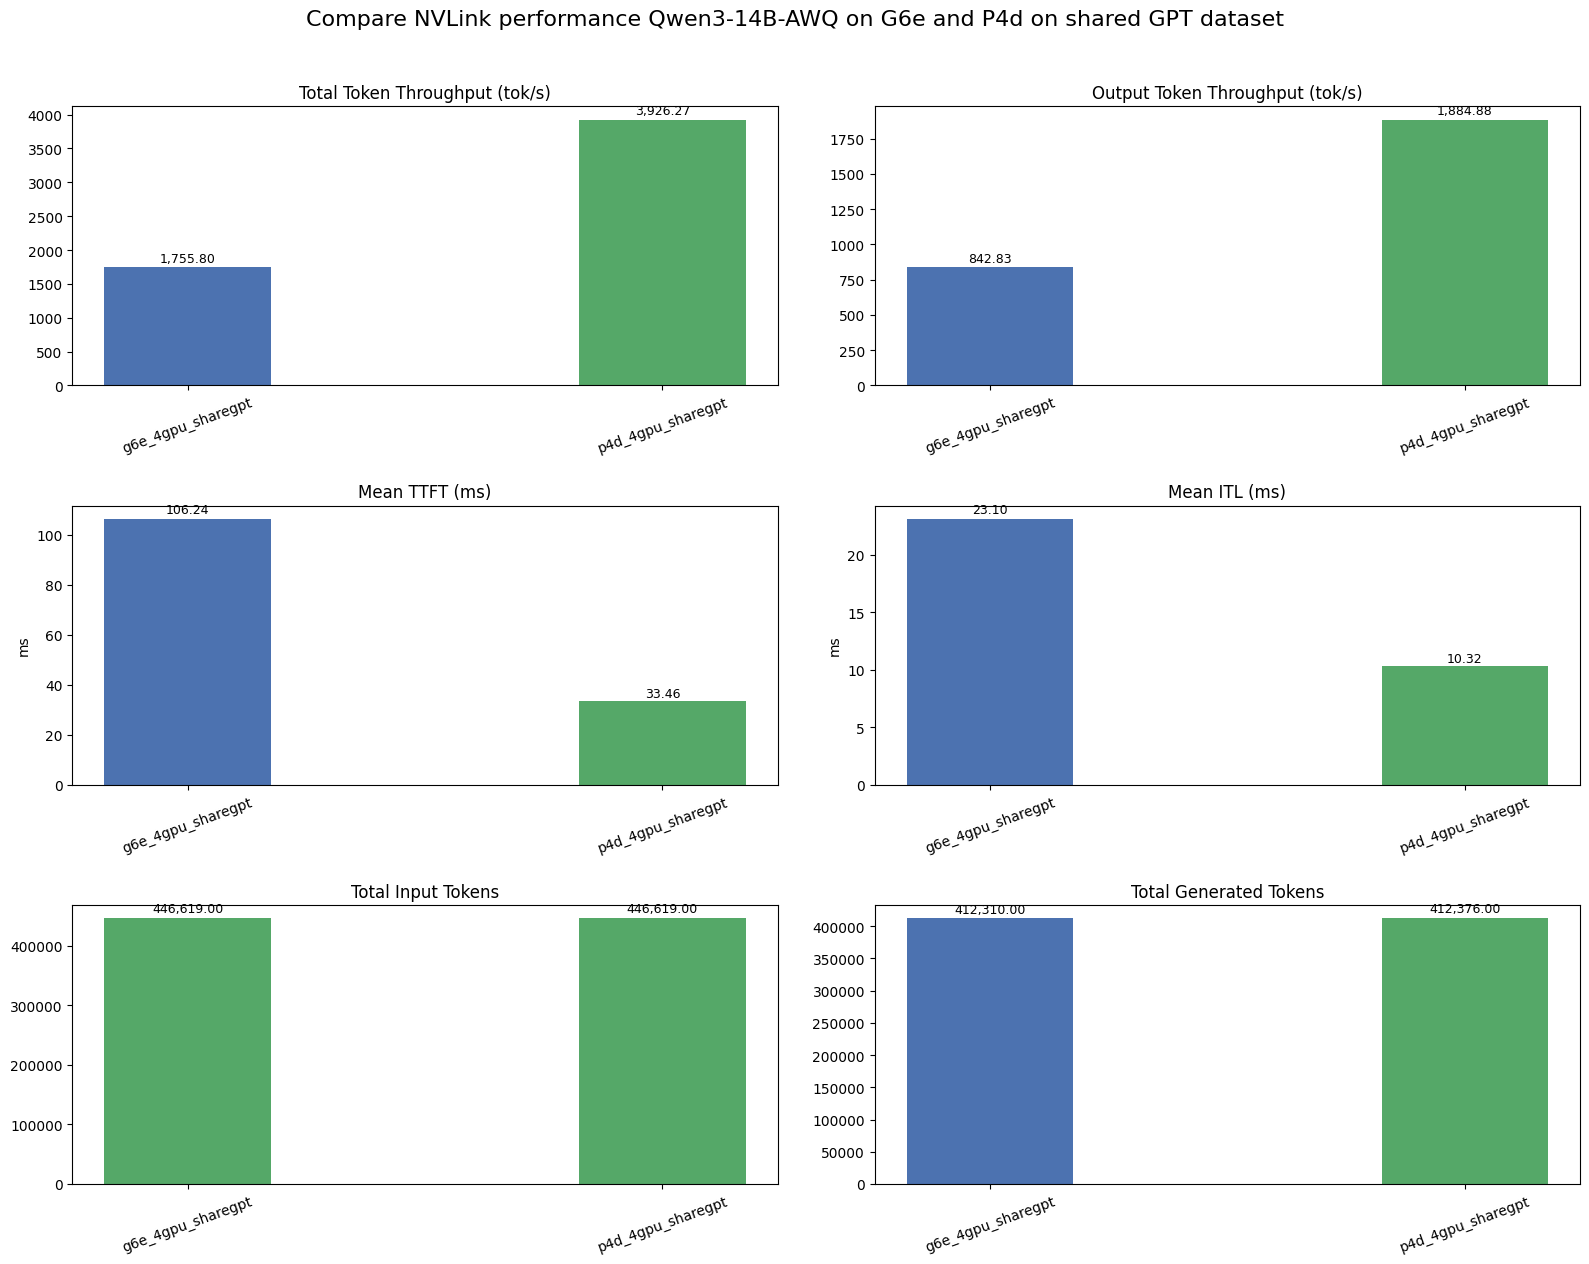

In [80]:
raw_results = '''

{"date": "20251015-213312", "setup": "g6e_4gpu_sharegpt", "env": "device=g6e, model=qwen3-awq, tp=4, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 489.19472349900025, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412310, "request_throughput": 4.088351537593981, "request_goodput": null, "output_throughput": 842.8341112326872, "total_token_throughput": 1755.8018489170302, "max_output_tokens_per_s": 1140.0, "max_concurrent_requests": 29, "mean_ttft_ms": 106.24191100208554, "median_ttft_ms": 77.75506200050586, "std_ttft_ms": 75.91013569190444, "p99_ttft_ms": 324.5684617504594, "mean_tpot_ms": 23.463096537094295, "median_tpot_ms": 22.440182543430854, "std_tpot_ms": 6.059279546668936, "p99_tpot_ms": 45.16157979327544, "mean_itl_ms": 23.099839525497227, "median_itl_ms": 17.726386999129318, "std_itl_ms": 26.774379117605267, "p99_itl_ms": 184.24454690008133}
{"date": "20251015-212751", "setup": "p4d_4gpu_sharegpt", "env": "device=p4d, model=qwen3-awq, tp=4, ds=sharegpt, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 218.781237641997, "completed": 2000, "total_input_tokens": 446619, "total_output_tokens": 412376, "request_throughput": 9.141551723337002, "request_goodput": null, "output_throughput": 1884.87826673141, "total_token_throughput": 3926.273611293934, "max_output_tokens_per_s": 2156.0, "max_concurrent_requests": 39, "mean_ttft_ms": 33.461267096485244, "median_ttft_ms": 28.977744001167594, "std_ttft_ms": 14.490953299751268, "p99_ttft_ms": 78.24796444001548, "mean_tpot_ms": 10.387220321780141, "median_tpot_ms": 10.221161628713203, "std_tpot_ms": 1.145089809257685, "p99_tpot_ms": 14.703573154833016, "mean_itl_ms": 10.32014471792419, "median_itl_ms": 9.18003900005715, "std_itl_ms": 5.435195151498526, "p99_itl_ms": 41.59328300374909}
'''
plot_vllm_bench_metrics(raw_results, cols=2, title="Compare NVLink performance Qwen3-14B-AWQ on G6e and P4d on shared GPT dataset")

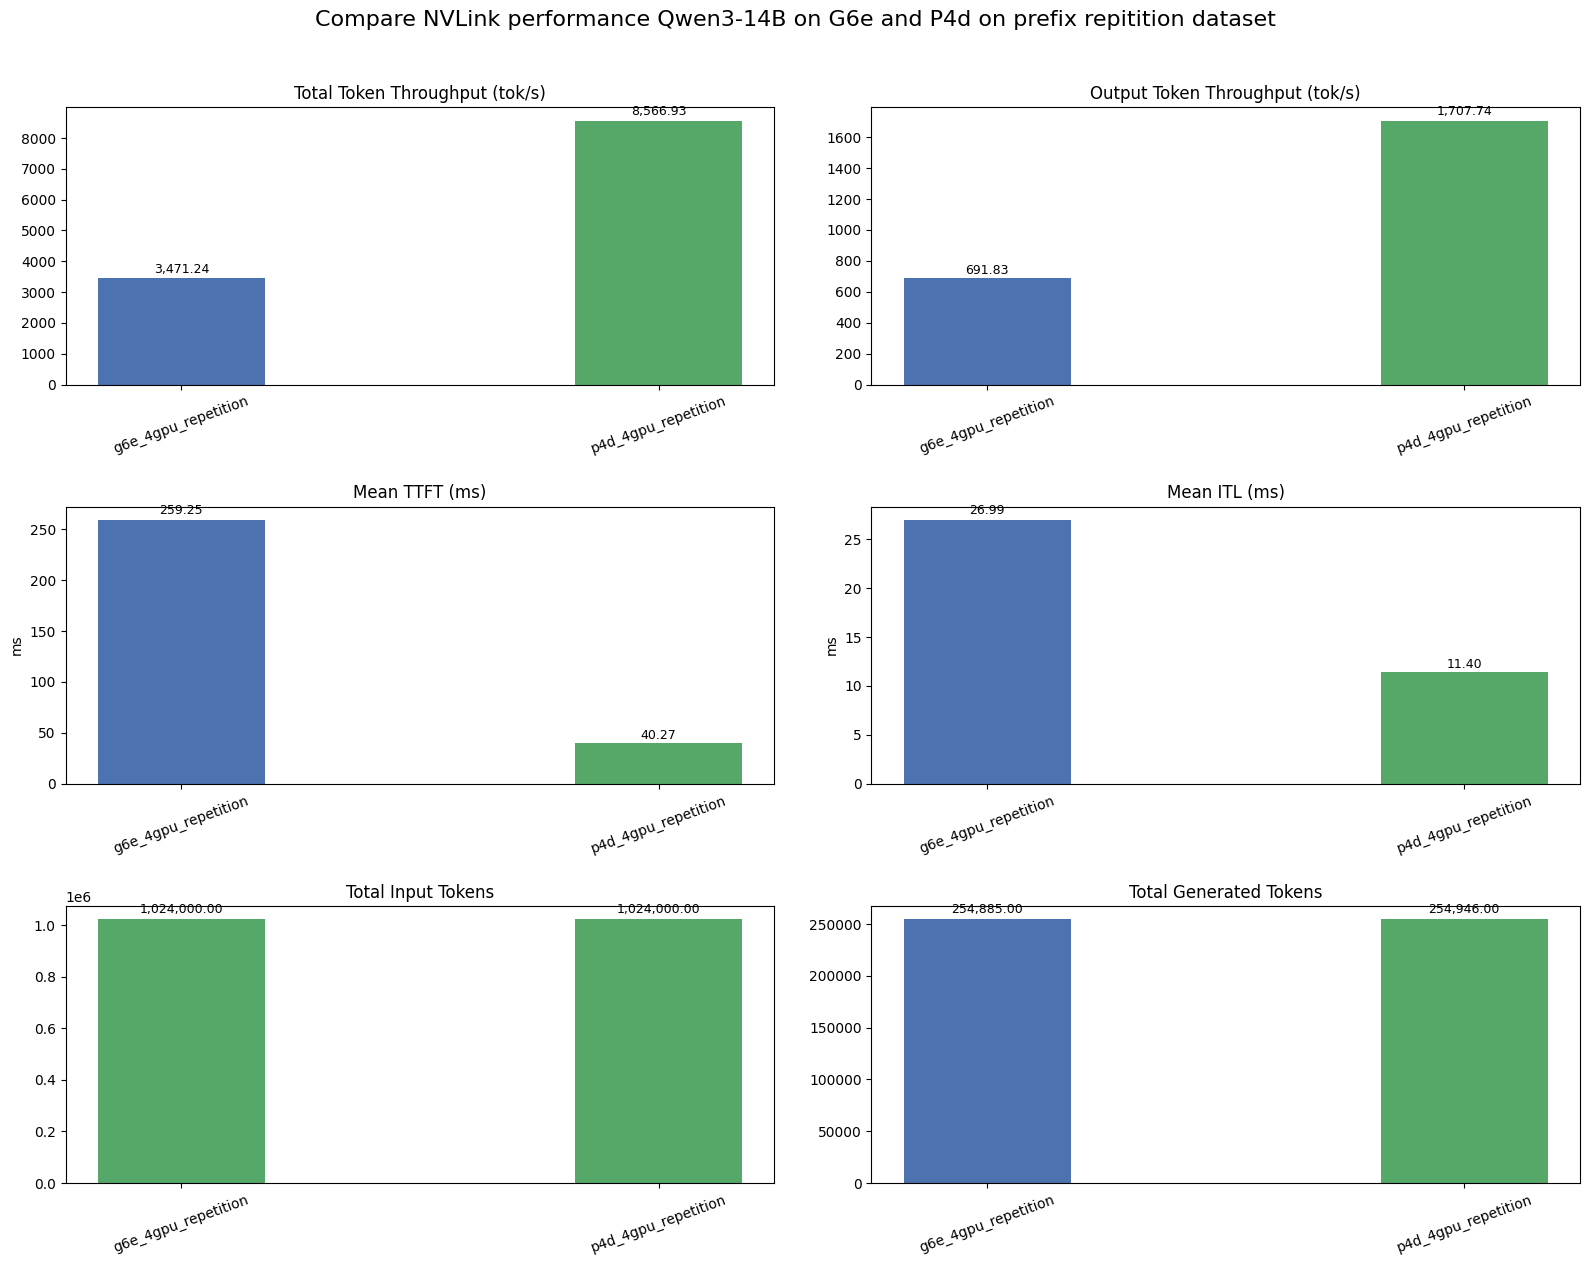

In [ ]:
raw_results = '''

{"date": "20251015-213956", "setup": "g6e_4gpu_repetition", "env": "device=g6e,  model=qwen3-awq, tp=4, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 368.4230991430013, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254885, "request_throughput": 5.428541274019606, "request_goodput": null, "output_throughput": 691.8268713142437, "total_token_throughput": 3471.240003612282, "max_output_tokens_per_s": 1140.0, "max_concurrent_requests": 38, "mean_ttft_ms": 259.24911071894167, "median_ttft_ms": 172.81536200243863, "std_ttft_ms": 201.93448956380533, "p99_ttft_ms": 779.6057660772931, "mean_tpot_ms": 26.990253536895583, "median_tpot_ms": 27.791609559051174, "std_tpot_ms": 1.8132137951567007, "p99_tpot_ms": 28.878620686872903, "mean_itl_ms": 26.987536876027203, "median_itl_ms": 17.74309699976584, "std_itl_ms": 34.49365537029954, "p99_itl_ms": 156.03413648030258}
{"date": "20251015-213627", "setup": "p4d_4gpu_repetition", "env": "device=p4d, model=qwen3-awq, tp=4, ds=prefix_repetition, rq_num=2000, rpm=20", "endpoint_type": "vllm", "backend": "vllm", "label": null, "model_id": "Qwen/Qwen3-14B-AWQ", "tokenizer_id": "Qwen/Qwen3-14B-AWQ", "num_prompts": 2000, "request_rate": 20.0, "burstiness": 1.0, "max_concurrency": 20, "duration": 149.2886607870023, "completed": 2000, "total_input_tokens": 1024000, "total_output_tokens": 254946, "request_throughput": 13.396864768272664, "request_goodput": null, "output_throughput": 1707.7385426060214, "total_token_throughput": 8566.933303961625, "max_output_tokens_per_s": 1892.0, "max_concurrent_requests": 38, "mean_ttft_ms": 40.27196815553543, "median_ttft_ms": 33.8650220001, "std_ttft_ms": 11.554691547957045, "p99_ttft_ms": 72.44597536126093, "mean_tpot_ms": 11.396871156135507, "median_tpot_ms": 11.436653488154539, "std_tpot_ms": 0.28852543451297114, "p99_tpot_ms": 11.638502017046026, "mean_itl_ms": 11.396208310013982, "median_itl_ms": 9.205226502672303, "std_itl_ms": 5.886366006899639, "p99_itl_ms": 36.83552169932219}'''

plot_vllm_bench_metrics(raw_results, cols=2, title="Compare NVLink performance Qwen3-14B-AWQ on G6e and P4d on prefix repitition dataset")